In [1]:
%%capture
%pip install qldpc
%pip install matplotlib

## Benchmarking state preparation circuits

Logical state preparation is an essential primitive for computing with a quantum error-correcting code.  But not all such circuits are created equal: some perform better than others.  One way to quantify the performance of a logical state preparation circuit is to consider the probability with which physical errors in this circuit propagate to logical errors.  We call this probability the logical error rate of the circuit.

More precisely, we consider:
1. An error-correcting code.
2. A circuit to prepare a logical state of that code.
3. A noise model that specifies how physical errors occur in the circuit.
4. A decoder that maps syndromes to inferred logical errors.

The decoder tries to infer which logical errors have occurred from syndrome data obtained in a follow-up error correction cycle (as well as possibly from syndromes provided by the state preparation circuit).  The logical error rate of the state preparation circuit is then the probability with which the decoder makes an incorrect inference about the occurrence of a logical error, so that after active error correction we end up with the logical wrong state.

The `qldpc.circuits.benchmarking` sub-module provides methods to compute the logical error rates of logical state preparation circuits.  

### imports and plotting code

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import sinter
import stim

from qldpc import circuits, codes, decoders

%matplotlib inline

In [3]:
def plot_sinter_results(stats: sinter.TaskStats) -> tuple[plt.Figure, plt.Axes]:
    """Plot sinter simulation results."""
    figure, axis = plt.subplots(figsize=(4, 3))
    sinter.plot_error_rate(
        ax=axis,
        stats=stats,
        x_func=lambda stats: stats.json_metadata["p"],
    )
    axis.axline(
        (0, 0),
        slope=1,
        color="k",
        linestyle=":",
        label=r"$p_{\mathrm{log}}=p_{\mathrm{phys}}$",
    )
    axis.set_ylabel("logical error rate")
    axis.set_xlabel("physical error rate")
    axis.loglog()
    axis.grid(which="both")
    figure.tight_layout()
    return figure, axis


def plot_error_and_discard_rates(
    error_rates: npt.NDArray[np.int_],
    logical_error_rates: npt.NDArray[np.int_],
    discard_rates: npt.NDArray[np.int_],
    label: str | None = None,
    figure: plt.Figure | None = None,
    axes: plt.Axes | None = None,
) -> tuple[plt.Figure, plt.Axes]:
    """Plot logical error rates and discard rates."""
    new_axes = axes is None
    if axes is None:
        figure, axes = plt.subplots(1, 2, sharex=True, figsize=(7, 3))

    # plot data
    axes[0].plot(error_rates, logical_error_rates, marker="o", linestyle="-", label=label)
    axes[1].plot(error_rates, discard_rates, marker="o", linestyle="-")

    if new_axes:
        axes[0].axline(
            (0, 0),
            slope=1,
            color="k",
            linestyle=":",
            label=r"$p_{\mathrm{log}}=p_{\mathrm{phys}}$",
        )
        axes[0].set_xlabel("physical error rate")
        axes[1].set_xlabel("physical error rate")
        axes[0].set_ylabel("logical error rate")
        axes[1].set_ylabel("discard rate")
        for axis in axes:
            axis.loglog()
            axis.grid(which="both")
    if figure is not None:
        figure.tight_layout()
    return figure, axes

### Steane code

A potential point of confusion: the decoder used to compute logical error rates below should be a `sinter.Decoder` that uses syndromes to infer which observables have been flipped, not a `qldpc.decoders.Decoder` that uses syndromes to infer which physical errors have occurred.

In [4]:
code = codes.SteaneCode()

# physical error rates to consider, and single-parameter family of noise models
error_rates = np.logspace(-3, -1, 5)
noise_model_family = circuits.DepolarizingNoiseModel

# use a lookup table decoder for these simulations
sinter_decoder = decoders.SinterDecoder(with_lookup=True, max_weight=2)

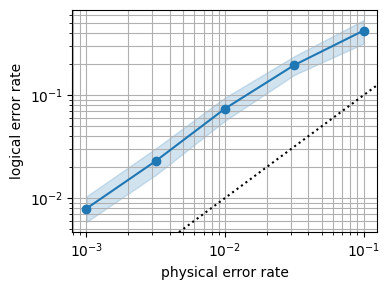

In [5]:
state_prep_circuit = circuits.get_encoding_circuit(code)

# build sinter tasks to perform our simulations
tasks = circuits.get_state_prep_diagnostic_tasks(
    code, state_prep_circuit, error_rates, noise_model_family
)

# run simulations and collect statistics on error rates
stats = sinter.collect(
    tasks=tasks,
    decoders=["custom"],
    custom_decoders={"custom": sinter_decoder},
    num_workers=os.cpu_count() - 2,
    max_shots=10**6,
    max_errors=100,
)

# plot simulation results!
plot_sinter_results(stats)
plt.show()

#### Fault-tolerant state preparation

In the example above, the logical error rate always exceeded the physical error rate.  That is because the state preparation circuit was not fault-tolerant.  Fortunately, the Steane code has well-known circuits for fault-tolerant logical state preparation.  The circuit below is taken from a [2016 paper by Goto](https://www.nature.com/articles/srep19578) (Figure 1c), and was used for hardware experiments in [arXiv:2603.04584](https://arxiv.org/abs/2603.04584).

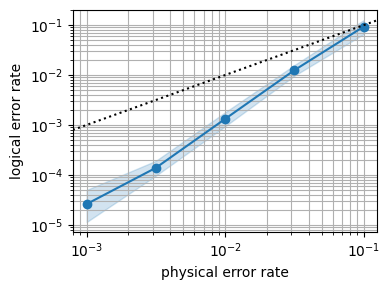

In [6]:
state_prep_circuit = stim.Circuit("""
    # non-fault-tolerant state preparation
    H 0 2 4
    CX 0 3 2 1 4 5
    CX 0 1 2 6 4 3
    CX 2 5 3 6
    # flag errors in a logical Z representative
    H 7
    CZ 7 1 7 3 7 5
    MX 7
""")

# build sinter tasks to perform our simulations
tasks = circuits.get_state_prep_diagnostic_tasks(
    code, state_prep_circuit, error_rates, noise_model_family
)

# run simulations and collect statistics on error rates
stats = sinter.collect(
    tasks=tasks,
    decoders=["custom"],
    custom_decoders={"custom": sinter_decoder},
    num_workers=os.cpu_count() - 2,
    max_shots=10**6,
    max_errors=100,
)

# plot simulation results!
plot_sinter_results(stats)
plt.show()

#### Post-selecting on flag qubit measurements

Many state preparation routines are repeat-until-success protocols, which use ancilla qubits to "flag" errors that may have occurred during state preparation.  If any flag qubit measurement has the wrong value (1 instead of 0), the state preparation routine restarts the protocol from scratch.  To identify the logical error rate of successful protocols, we need to post-select on the flag measurement outcomes.

Post-selection on state preparation flags is in theory supported in `qldpc` by passing the keyword argument `post_select_on_flags=True` to `circuits.get_state_prep_diagnostic_tasks`.  Unfortunately, a [`sinter` bug](https://github.com/quantumlib/Stim/pull/844) currently prevents us from post-selecting in `sinter` simulations, so we instead use the `circuits.get_logical_error_and_discard_rates` method.  Post-selection with this method requires identifying the detectors to post-select on.

`circuits.get_state_prep_diagnostic_tasks` adds a detector for each measurement in the provided circuit, and saves these detectors to `task.json_metadata["flags"]`.  We can therefore pass this variable to `circuits.get_logical_error_and_discard_rate` in order to post-select on all flags in the circuit.

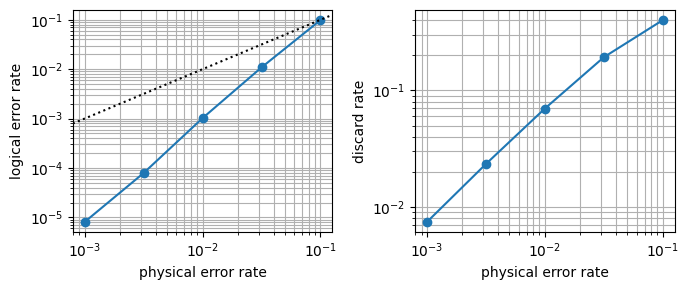

In [7]:
logical_error_rates = np.empty(len(tasks))
discard_rates = np.empty(len(tasks))
for tt, task in enumerate(tasks):
    logical_error_rates[tt], discard_rates[tt] = circuits.get_logical_error_and_discard_rate(
        task.circuit,
        sinter_decoder,
        num_samples=10**6,
        post_select=task.json_metadata["flags"],
    )

plot_error_and_discard_rates(error_rates, logical_error_rates, discard_rates)
plt.show()

#### A nontrivial example

The example above is "trivial" in the sense that post-selection was not required to prepare a logical |0> state fault tolerantly.  As a nontrivial example, we consider a "Clifford proxy" of the |H> state preparation circuit in Figure 3(b) of [arXiv:2603.04584](https://arxiv.org/abs/2603.04584v1).  The Clifford proxy modifies a few gates in the circuit so as to prepare |+> instead of |H>, making the circuit amenable to `stim` and `sinter` simulations.

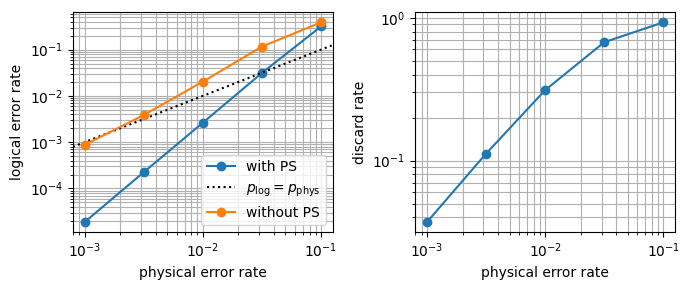

In [8]:
hadamard_prep_circuit = """
    H 1 2 3 7
    CX 1 0 3 5 7 6
    CX 1 4 2 6
    CX 2 0 1 5 3 6
    ########################################################
    TPP X1*X6  # "T-like" pi/4 rotation about a Pauli string
    ########################################################
    CX 7 6 6 4
    MX 7
    DETECTOR rec[-1]
    S_DAG 0 1 2 3 4 5 6  # logical S gate
    ##################################################################
    # logical stabilizer measurement
    H 8
    CX 8 9
    ###########################
    # controlled-Hadamard gates
    CH 8 3 9 5
    CH 8 0 9 2
    CH 8 1 9 6
    CH 8 4
    ###########################
    CX 8 9
    MX 8
    MZ 9
    DETECTOR rec[-2]
    DETECTOR rec[-1]
    ##################################################################
    # code stabilizer measurements
    H 11
    CX 3 10 11 2
    CX 2 10 11 3
    CX 1 10 11 4
    CX 4 10 11 1
    MZ 10
    MX 11
    DETECTOR rec[-2]
    DETECTOR rec[-1]
"""
plus_prep_circuit = stim.Circuit(hadamard_prep_circuit.replace("TPP", "SPP").replace("CH", "CX"))

# build sinter tasks
tasks = circuits.get_state_prep_diagnostic_tasks(
    code, plus_prep_circuit, error_rates, noise_model_family
)

# run simulations with no post-selection
logical_error_rates_nps = np.empty(len(tasks))
discard_rates_nps = np.empty(len(tasks))
for tt, task in enumerate(tasks):
    logical_error_rates_nps[tt], discard_rates_nps[tt] = circuits.get_logical_error_and_discard_rate(
        task.circuit,
        sinter_decoder,
        num_samples=10**6,
    )

# run simulations with post-selection
logical_error_rates = np.empty(len(tasks))
discard_rates = np.empty(len(tasks))
for tt, task in enumerate(tasks):
    logical_error_rates[tt], discard_rates[tt] = circuits.get_logical_error_and_discard_rate(
        task.circuit,
        sinter_decoder,
        num_samples=10**6,
        post_select=task.json_metadata["flags"],
    )

# plot results
figure, axes = plot_error_and_discard_rates(error_rates, logical_error_rates, discard_rates, label="with PS")
plot_error_and_discard_rates(error_rates, logical_error_rates_nps, discard_rates_nps, label="without PS", axes=axes)
axes[0].legend(loc="best")
figure.tight_layout()
plt.show()